In [14]:
import numpy as np
import scipy as sp
import scipy.sparse, scipy.io, scipy.optimize
from scipy.special import expit
from scipy.sparse.linalg import eigsh

import matplotlib.pyplot as plt
import matplotlib as mpl
import time
import pickle
from pathlib import Path

%matplotlib inline

CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a', # Color blind color cycle
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=CB_color_cycle) 

clip_01 = lambda M : np.clip(M, a_min=0, a_max=1)

from DataPreprocess import *

In [15]:
with open('./matrices/results.pkl', 'rb') as f:
    results = pickle.load(f)

In [16]:
def unify_all_data_hierarchical(results_dict=None, base_dir='./matrices'):
    """
    data[dataset][graph_type][method][rank] = {'U': array, 'V': array, 'source': str}
    """
    # 1. from Daniel
    data = {}
    if results_dict is not None:
        dataset_mapping = {
            'HEP': 'CA-HepPh',
            'FB': 'Facebook',
            'Wiki': 'Wiki-Vote'
        }
        
        def parse_dict_key(key, dataset):
            if key == 'LPCA16':
                return 'original', 'lpca', 16
            elif key == 'LPCAEFD':
                rank_map = {'CA-HepPh': 32, 'Facebook': 32, 'Wiki-Vote': 48}
                return 'original', 'lpca', rank_map.get(dataset, 32)
            elif key == 'LPCAEFD-16':
                return 'original', 'lpca', 32
            elif key == 'LPCAedge_swap':
                rank_map = {'CA-HepPh': 96, 'Facebook': 96, 'Wiki-Vote': 80}
                return 'edge_swap', 'lpca', rank_map.get(dataset, 96)
            elif key == 'LPCAerdosrenyi':
                rank_map = {'CA-HepPh': 64, 'Facebook': 80, 'Wiki-Vote': 48}
                return 'erdos_renyi', 'lpca', rank_map.get(dataset, 64)
            elif key == 'TSVD1':
                rank_map = {'CA-HepPh': 16, 'Facebook': 16, 'Wiki-Vote': 48}
                return 'original', 'tsvd', rank_map.get(dataset, 16)
            elif key == 'TSVD2':
                return 'original', 'tsvd', 128
            else:
                return None, None, None
        
        for dataset_key, methods in results_dict.items():
            dataset_name = dataset_mapping.get(dataset_key, dataset_key)
            
            if dataset_name not in data:
                data[dataset_name] = {}
            
            for method_key, (U, V) in methods.items():
                graph_type, method, rank = parse_dict_key(method_key, dataset_name)
                
                if graph_type is None:
                    print(f"Warning: Cannot parse '{method_key}'")
                    continue
                
                if graph_type not in data[dataset_name]:
                    data[dataset_name][graph_type] = {}
                if method not in data[dataset_name][graph_type]:
                    data[dataset_name][graph_type][method] = {}
                
                data[dataset_name][graph_type][method][rank] = {
                    'U': U,
                    'V': V,
                    'source': 'dict',
                    'original_key': method_key
                }
                print(f"Loaded from dict: {dataset_name}/{graph_type}/{method}/rank{rank}")
    
    # 2. from Yuxin
    base_path = Path(base_dir)
    if base_path.exists():
        for dataset_folder in base_path.iterdir():
            if not dataset_folder.is_dir():
                continue
            
            dataset_name = dataset_folder.name
            
            if dataset_name not in data:
                data[dataset_name] = {}
            
            u_files = {}
            v_files = {}
            
            for file in dataset_folder.glob('*.npy'):
                filename = file.stem
                
                if not (filename.startswith('U_') or filename.startswith('V_')):
                    continue
                
                matrix_type = filename[0]  # 'U' or 'V'
                parts = filename[2:].split('_')
                
                # raph_type, method, rank
                if 'edge' in parts and 'swap' in parts:
                    # lpca_edge_swap_rank32
                    method = parts[0]
                    graph_type = 'edge_swap'
                    rank_str = [p for p in parts if 'rank' in p][0]
                elif 'erdos' in parts or 'renyi' in parts:
                    # lpca_erdos_renyi_rank32
                    method = parts[0]
                    graph_type = 'erdos_renyi'
                    rank_str = [p for p in parts if 'rank' in p][0]
                else:
                    # lpca_rank16 或 tsvd_rank128
                    method = parts[0]
                    graph_type = 'original'
                    rank_str = parts[-1]
                
                rank = int(rank_str.replace('rank', ''))
                
                key = (graph_type, method, rank)
                if matrix_type == 'U':
                    u_files[key] = file
                else:
                    v_files[key] = file
            
            for key in u_files:
                if key in v_files:
                    graph_type, method, rank = key
                    
                    if graph_type not in data[dataset_name]:
                        data[dataset_name][graph_type] = {}
                    if method not in data[dataset_name][graph_type]:
                        data[dataset_name][graph_type][method] = {}
                    
                    if rank not in data[dataset_name][graph_type][method]:
                        U = np.load(u_files[key])
                        V = np.load(v_files[key])
                        
                        data[dataset_name][graph_type][method][rank] = {
                            'U': U,
                            'V': V,
                            'source': 'file',
                            'U_path': str(u_files[key]),
                            'V_path': str(v_files[key])
                        }
                        print(f"Loaded from file: {dataset_name}/{graph_type}/{method}/rank{rank}")
    
    return data

def get_matrix(data, dataset, graph_type, method, rank):
    try:
        entry = data[dataset][graph_type][method][rank]
        return entry['U'], entry['V']
    except KeyError as e:
        raise KeyError(
            f"Not found: {dataset}/{graph_type}/{method}/rank{rank}\n"
            f"Available datasets: {list(data.keys())}\n"
            f"Error: {e}"
        )

all_data = unify_all_data_hierarchical(results_dict=results, base_dir='./matrices')
U, V = get_matrix(all_data, 'CA-HepPh', 'original', 'lpca', 16)
U2, V2 = get_matrix(all_data, 'CA-GrQc', 'edge_swap', 'lpca', 32)

Loaded from dict: CA-HepPh/original/lpca/rank16
Loaded from dict: CA-HepPh/original/lpca/rank32
Loaded from dict: CA-HepPh/edge_swap/lpca/rank96
Loaded from dict: CA-HepPh/erdos_renyi/lpca/rank64
Loaded from dict: CA-HepPh/original/tsvd/rank16
Loaded from dict: CA-HepPh/original/tsvd/rank128
Loaded from dict: Facebook/original/lpca/rank16
Loaded from dict: Facebook/original/lpca/rank32
Loaded from dict: Facebook/edge_swap/lpca/rank96
Loaded from dict: Facebook/erdos_renyi/lpca/rank80
Loaded from dict: Facebook/original/tsvd/rank16
Loaded from dict: Facebook/original/tsvd/rank128
Loaded from dict: Wiki-Vote/original/lpca/rank16
Loaded from dict: Wiki-Vote/original/lpca/rank32
Loaded from dict: Wiki-Vote/original/lpca/rank48
Loaded from dict: Wiki-Vote/edge_swap/lpca/rank80
Loaded from dict: Wiki-Vote/erdos_renyi/lpca/rank48
Loaded from dict: Wiki-Vote/original/tsvd/rank48
Loaded from dict: Wiki-Vote/original/tsvd/rank128
Loaded from file: cora/original/tsvd/rank16
Loaded from file: cora

In [17]:
adj_hep = read_cahepph(ca_hepph_path='./data/CA-HepPh.txt')
adj_cora = read_cora(content_path="./data/cora/cora.content", cites_path="./data/cora/cora.cites")
adj_grqc = read_cag_fb_wiki(ca_grqc_path="./data/CA-GrQc.txt")
adj_pubmed = read_pubmed(folder_path="./data/Pubmed/data/")
adj_fb = read_cag_fb_wiki(ca_grqc_path="./data/facebook_combined.txt")
adj_wiki = read_cag_fb_wiki(ca_grqc_path="./data/Wiki-Vote.txt")

Before GC: (12006, 12006) nnz = 236978
After GC: (11204, 11204) nnz = 235238
Mean degree = 20.995894323455907
Before GC: (2708, 2708) nnz = 10556
Mean degree = 3.8980799
Shape: (5241, 5241) nnz = 28968
Mean degree = 5.527189467658844
Nodes = 19717
Mean degree = 4.496170817061419
Shape: (4039, 4039) nnz = 176468
Mean degree = 43.69101262688784
Shape: (7115, 7115) nnz = 201524
Mean degree = 28.32382290934645


In [18]:
def factor_TSVD(adj, k):
    w, v = np.linalg.eigh(np.array(adj.todense()))
    order = np.argsort(np.abs(w))[::-1]
    w = w[order[:k]]
    v = v[:,order[:k]]
    U_tsvd, V_tsvd = v * np.sqrt(np.abs(w))[None,:], (np.sign(w)*np.sqrt(np.abs(w)))[:,None] * v.T
    return U_tsvd, V_tsvd

def tsvd_fit(adj, rank):
    U_tsvd, V_tsvd = factor_TSVD(adj, rank)
    frob_error_norm = np.linalg.norm(clip_01(U_tsvd@V_tsvd) - adj) / sp.sparse.linalg.norm(adj)
    print("TSVD Frob norm error: ", frob_error_norm)
    return U_tsvd, V_tsvd

all_data['Wiki-Vote']['original']['tsvd'][32] = {'U':0, 'V':0}
all_data['Wiki-Vote']['original']['tsvd'][32]['U'], all_data['Wiki-Vote']['original']['tsvd'][32]['V'] =\
    tsvd_fit(adj_wiki, 32)
all_data['Facebook']['original']['tsvd'][32] = {'U':0, 'V':0}
all_data['Facebook']['original']['tsvd'][32]['U'], all_data['Facebook']['original']['tsvd'][32]['V'] =\
    tsvd_fit(adj_fb, 32)
all_data['CA-HepPh']['original']['tsvd'][32] = {'U':0, 'V':0}
all_data['CA-HepPh']['original']['tsvd'][32]['U'], all_data['CA-HepPh']['original']['tsvd'][32]['V'] =\
    tsvd_fit(adj_fb, 32)

TSVD Frob norm error:  0.8203856988421623
TSVD Frob norm error:  0.6620841051325671
TSVD Frob norm error:  0.6620841051325671


In [19]:
# 1. adj matrix
def recon_matrix(U, V, method="lpca"):
    logits = U @ V
    if method == "lpca":
        return expit(logits)
    elif method == "tsvd":
        return clip_01(logits)
    
def adjacency_spectrum_true(adj, k=50):
    A = adj.tocsr()
    w, _ = eigsh(A, k=k, which="LM")
    w = np.abs(w)
    idx = np.argsort(w)[::-1]
    return w[idx]

def adjacency_spectrum_from_factors(U, V, method="lpca", k=50):
    A_hat = recon_matrix(U, V, method=method)
    A_hat = 0.5 * (A_hat + A_hat.T)
    
    w, _ = np.linalg.eigh(A_hat)
    w = np.abs(w)
    idx = np.argsort(w)[::-1]
    return w[idx][:k]

def eigen_l2_error(eig_true, eig_hat):
    k = min(len(eig_true), len(eig_hat))
    diff = eig_true[:k] - eig_hat[:k]
    return np.sqrt(np.mean(diff**2))

In [ ]:
def compute_eigenvalue_results(all_data, dataset_configs, k=50):
    results = {}
    
    for config in dataset_configs:
        dataset = config['dataset']
        adj = config['adj']
        lpca_ranks = config.get('lpca_ranks', [])
        tsvd_ranks = config.get('tsvd_ranks', [])
        print("=" * 60)
        print(f"{dataset}:")
        
        try:
            eig_true = adjacency_spectrum_true(adj, k=k)
            
            results[dataset] = {
                'eig_true': eig_true,
                'lpca': {},
                'tsvd': {}
            }
            
            for rank in lpca_ranks:
                U, V = get_matrix(all_data, dataset, 'original', 'lpca', rank)
                eig_lpca = adjacency_spectrum_from_factors(U, V, method='lpca', k=k)
                err = eigen_l2_error(eig_true, eig_lpca)
                results[dataset]['lpca'][rank] = {'eig': eig_lpca, 'err': err}
                print(f"  LPCA {rank} L2 error: {err:.6f}")
            
            for rank in tsvd_ranks:
                U, V = get_matrix(all_data, dataset, 'original', 'tsvd', rank)
                eig_tsvd = adjacency_spectrum_from_factors(U, V, method='tsvd', k=k)
                err = eigen_l2_error(eig_true, eig_tsvd)
                results[dataset]['tsvd'][rank] = {'eig': eig_tsvd, 'err': err}
                print(f"  TSVD {rank} L2 error: {err:.6f}")
        
        except Exception as e:
            print(f"ERROR: {e}")
            results[dataset] = {'error': str(e)}
    
    print("=" * 60)
    return results

dataset_configs = [
    {'dataset': 'CA-GrQc', 'adj': adj_grqc, 'lpca_ranks': [16], 'tsvd_ranks': [16, 128]},
    {'dataset': 'CA-HepPh', 'adj': adj_hep, 'lpca_ranks': [16, 32], 'tsvd_ranks': [32, 128]},
    {'dataset': 'cora', 'adj': adj_cora, 'lpca_ranks': [16], 'tsvd_ranks': [16, 128]},
    {'dataset': 'Pubmed', 'adj': adj_pubmed, 'lpca_ranks': [16, 32], 'tsvd_ranks': [32, 128]},
    {'dataset': 'Facebook', 'adj': adj_fb, 'lpca_ranks': [16, 32], 'tsvd_ranks': [32, 128]},
    {'dataset': 'Wiki-Vote', 'adj': adj_wiki, 'lpca_ranks': [16, 32, 48], 'tsvd_ranks': [48, 128]}
]

results = compute_eigenvalue_results(all_data, dataset_configs, k=50)

CA-GrQc:
  LPCA 16 L2 error: 0.000000
  TSVD 16 L2 error: 6.668337
  TSVD 128 L2 error: 0.379803
CA-HepPh:
  LPCA 16 L2 error: 0.609133
  LPCA 32 L2 error: 0.000000
  TSVD 32 L2 error: 19.347936
  TSVD 128 L2 error: 1.031186
cora:
  LPCA 16 L2 error: 0.000008
  TSVD 16 L2 error: 4.578369
  TSVD 128 L2 error: 0.291876
Pubmed:
  LPCA 16 L2 error: 0.168782
  LPCA 32 L2 error: 0.000000
  TSVD 32 L2 error: 5.604813
  TSVD 128 L2 error: 1.884965
Facebook:
  LPCA 16 L2 error: 0.322913
  LPCA 32 L2 error: 0.097289
  TSVD 32 L2 error: 10.096506
  TSVD 128 L2 error: 1.555718
Wiki-Vote:
  LPCA 16 L2 error: 6.707778
  LPCA 32 L2 error: 3.757216
  LPCA 48 L2 error: 1.772514
  TSVD 48 L2 error: 5.514422
  TSVD 128 L2 error: 5.099841



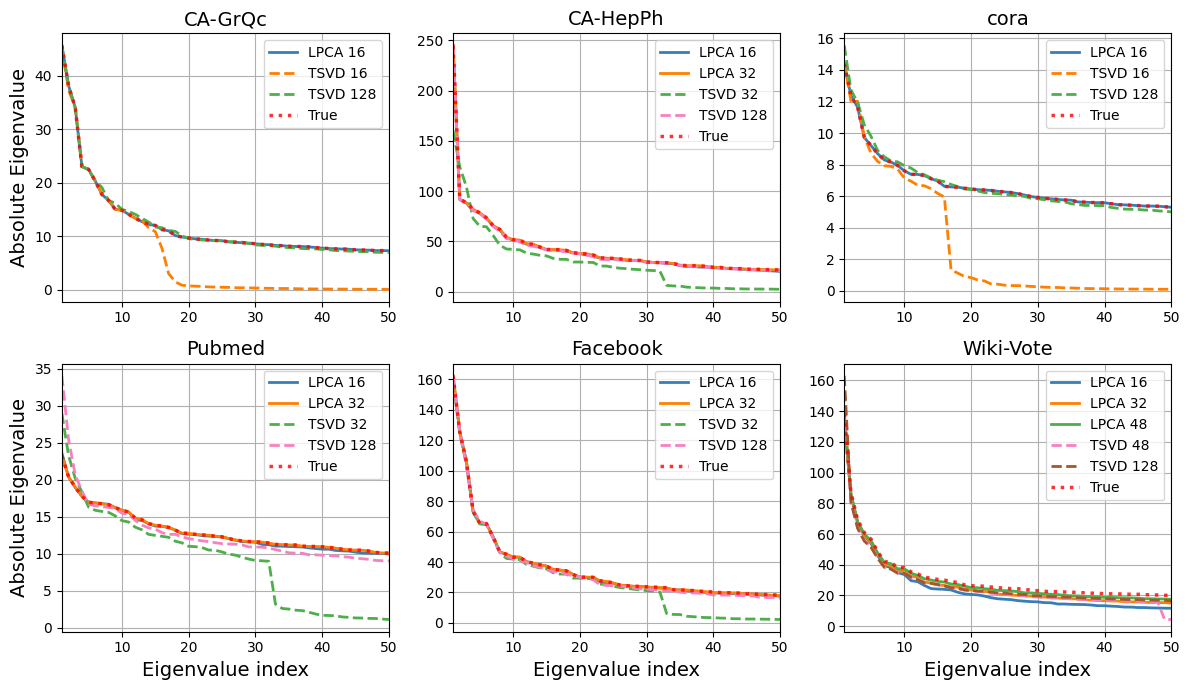

In [42]:
def plot_eigenvalue_results(results, dataset_order=None, k=50, figsize=(12, 7)):
    if dataset_order is None:
        dataset_order = list(results.keys())
    
    n_panels = min(len(dataset_order), 6)
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.flat
    
    for idx in range(n_panels):
        ax = axes[idx]
        dataset = dataset_order[idx]
        
        if dataset not in results or 'error' in results[dataset]:
            ax.set_title(f'{dataset}')
            continue
        
        data = results[dataset]
        eig_true = data['eig_true']
        x = np.arange(1, len(eig_true) + 1)
        
        for rank in sorted(data['lpca'].keys()):
            eig = data['lpca'][rank]['eig']
            err = data['lpca'][rank]['err']
            ax.plot(x[:len(eig)], eig, label=f'LPCA {rank}', linewidth=2)
        
        for rank in sorted(data['tsvd'].keys()):
            eig = data['tsvd'][rank]['eig']
            err = data['tsvd'][rank]['err']
            ax.plot(x[:len(eig)], eig, label=f'TSVD {rank}', linewidth=2, linestyle='--')
        
        ax.plot(x, eig_true, label='True', linewidth=2.5, linestyle=':', color='red', alpha=0.8)
        
        if idx in [3, 4, 5]:
            ax.set_xlabel('Eigenvalue index', fontsize=14)
        if idx in [0, 3]:
            ax.set_ylabel('Absolute Eigenvalue', fontsize=14)
        ax.set_title(f'{dataset}', fontsize=14)
        ax.grid()
        ax.legend(fontsize=10, loc='best')
        ax.set_xlim(1, k)
    
    for idx in range(n_panels, 6):
        axes[idx].axis('off')
    
    plt.tight_layout()
    return fig

fig = plot_eigenvalue_results(results, k=50)
plt.savefig('./figs/ext-adj.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
# 2. laplacian
def recon_matrix(U, V, method="lpca"):
    logits = U @ V
    if method == "lpca":
        return expit(logits)
    elif method == "tsvd":
        return clip_01(logits)
    
def to_symmetric(A):
    if scipy.sparse.issparse(A):
        A = A.tocsr()
        A_sym = 0.5 * (A + A.T)
        return A_sym.toarray()
    else:
        return 0.5 * (A + A.T)

def normalized_laplacian_from_dense(A):
    """
    L_sym = I - D^{-1/2} A D^{-1/2}
    """
    n = A.shape[0]
    d = A.sum(axis=1)
    d = np.asarray(d).flatten()
    d[d == 0] = 1.0
    inv_sqrt_d = 1.0 / np.sqrt(d)
    D_inv_sqrt = np.diag(inv_sqrt_d)
    L = np.eye(n) - D_inv_sqrt @ A @ D_inv_sqrt
    # L = 0.5 * (L + L.T)  # ensure symmetry
    return L

def smallest_k_eigenvalues(L, k=50):
    L = np.asarray(L)
    w, _ = np.linalg.eigh(L)
    w_sorted = np.sort(w)
    return w_sorted[:k]

def laplacian_spectrum_true(adj, k=50):
    A_true = to_symmetric(adj)
    L_true = normalized_laplacian_from_dense(A_true)
    eig_true = smallest_k_eigenvalues(L_true, k=k)
    return eig_true

def laplacian_spectrum_from_factors(U, V, method="lpca", k=50):
    A_hat = recon_matrix(U, V, method=method)  # dense
    A_hat_sym = to_symmetric(A_hat)
    L_hat = normalized_laplacian_from_dense(A_hat_sym)
    eig_hat = smallest_k_eigenvalues(L_hat, k=k)
    return eig_hat

def eigen_l2_error(eig_true, eig_hat):
    k = min(len(eig_true), len(eig_hat))
    diff = eig_true[:k] - eig_hat[:k]
    return np.sqrt(np.mean(diff**2))

In [37]:
def compute_laplacian_eigenvalue_results(all_data, dataset_configs, k=50):
    results = {}
    
    for config in dataset_configs:
        dataset = config['dataset']
        adj = config['adj']
        lpca_ranks = config.get('lpca_ranks', [])
        tsvd_ranks = config.get('tsvd_ranks', [])
        print("=" * 60)
        print(f"{dataset}:")
        
        try:
            eig_true = laplacian_spectrum_true(adj, k=k)
            
            results[dataset] = {
                'eig_true': eig_true,
                'lpca': {},
                'tsvd': {}
            }
            
            for rank in lpca_ranks:
                U, V = get_matrix(all_data, dataset, 'original', 'lpca', rank)
                eig_lpca = laplacian_spectrum_from_factors(U, V, method='lpca', k=k)
                err = eigen_l2_error(eig_true, eig_lpca)
                results[dataset]['lpca'][rank] = {'eig': eig_lpca, 'err': err}
                print(f"  LPCA {rank} L2 error: {err:.6f}")
            
            for rank in tsvd_ranks:
                U, V = get_matrix(all_data, dataset, 'original', 'tsvd', rank)
                eig_tsvd = laplacian_spectrum_from_factors(U, V, method='tsvd', k=k)
                err = eigen_l2_error(eig_true, eig_tsvd)
                results[dataset]['tsvd'][rank] = {'eig': eig_tsvd, 'err': err}
                print(f"  TSVD {rank} L2 error: {err:.6f}")
        
        except Exception as e:
            print(f"ERROR: {e}")
            results[dataset] = {'error': str(e)}
    
    print("=" * 60)
    return results


dataset_configs = [
    {'dataset': 'CA-GrQc', 'adj': adj_grqc, 'lpca_ranks': [16], 'tsvd_ranks': [16, 128]},
    {'dataset': 'CA-HepPh', 'adj': adj_hep, 'lpca_ranks': [16, 32], 'tsvd_ranks': [32, 128]},
    {'dataset': 'cora', 'adj': adj_cora, 'lpca_ranks': [16], 'tsvd_ranks': [16, 128]},
    {'dataset': 'Pubmed', 'adj': adj_pubmed, 'lpca_ranks': [16, 32], 'tsvd_ranks': [32, 128]},
    {'dataset': 'Facebook', 'adj': adj_fb, 'lpca_ranks': [16, 32], 'tsvd_ranks': [32, 128]},
    {'dataset': 'Wiki-Vote', 'adj': adj_wiki, 'lpca_ranks': [16, 32, 48], 'tsvd_ranks': [48, 128]}
]

laplacian_results = compute_laplacian_eigenvalue_results(all_data, dataset_configs, k=50)

CA-GrQc:
  LPCA 16 L2 error: 0.000000
  TSVD 16 L2 error: 0.822578
  TSVD 128 L2 error: 0.378242
CA-HepPh:
  LPCA 16 L2 error: 0.000759
  LPCA 32 L2 error: 0.000000
  TSVD 32 L2 error: 0.645500
  TSVD 128 L2 error: 0.254941
cora:
  LPCA 16 L2 error: 0.000000
  TSVD 16 L2 error: 0.867749
  TSVD 128 L2 error: 0.444450
Pubmed:
  LPCA 16 L2 error: 0.000497
  LPCA 32 L2 error: 0.000000
  TSVD 32 L2 error: 0.732924
  TSVD 128 L2 error: 0.571445
Facebook:
  LPCA 16 L2 error: 0.000881
  LPCA 32 L2 error: 0.000118
  TSVD 32 L2 error: 0.544843
  TSVD 128 L2 error: 0.265141
Wiki-Vote:
  LPCA 16 L2 error: 0.006116
  LPCA 32 L2 error: 0.002077
  LPCA 48 L2 error: 0.002167
  TSVD 48 L2 error: 0.692073
  TSVD 128 L2 error: 0.673348


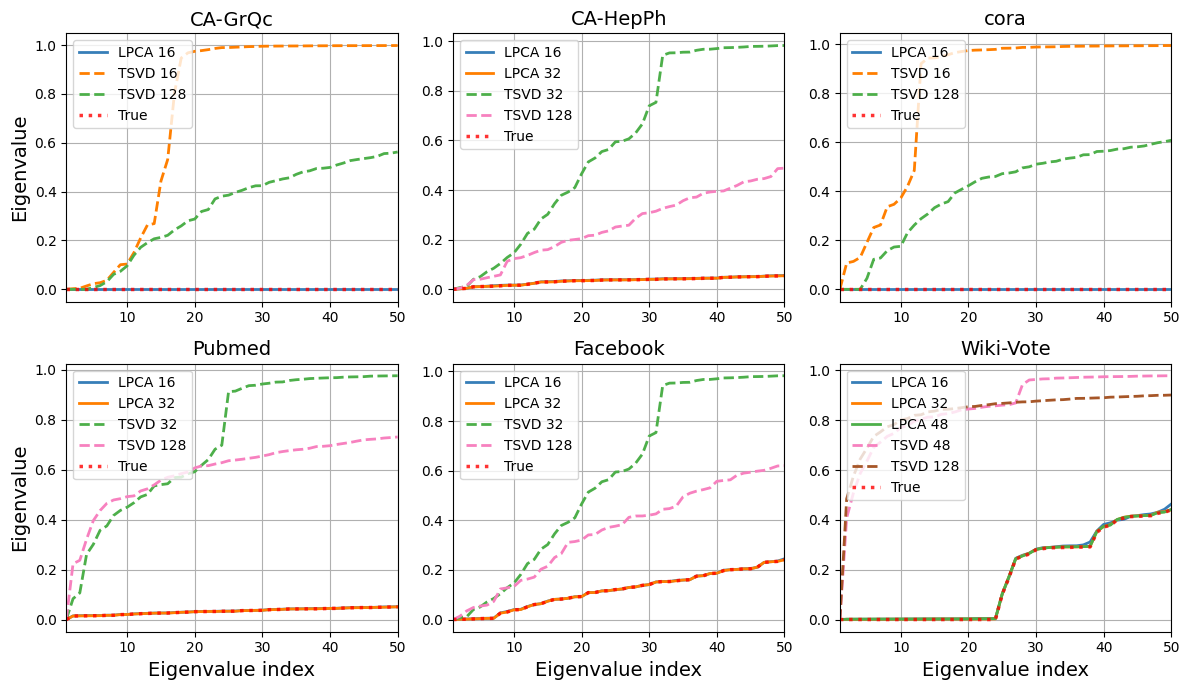

In [43]:
def plot_laplacian_eigenvalue_results(results, dataset_order=None, k=50, figsize=(12, 7)):
    if dataset_order is None:
        dataset_order = list(results.keys())
    
    n_panels = min(len(dataset_order), 6)
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.flat
    
    for idx in range(n_panels):
        ax = axes[idx]
        dataset = dataset_order[idx]
        
        if dataset not in results or 'error' in results[dataset]:
            ax.set_title(f'{dataset}')
            continue
        
        data = results[dataset]
        eig_true = data['eig_true']
        x = np.arange(1, len(eig_true) + 1)
        
        for rank in sorted(data['lpca'].keys()):
            eig = data['lpca'][rank]['eig']
            err = data['lpca'][rank]['err']
            ax.plot(x[:len(eig)], eig, label=f'LPCA {rank}', linewidth=2)
        
        for rank in sorted(data['tsvd'].keys()):
            eig = data['tsvd'][rank]['eig']
            err = data['tsvd'][rank]['err']
            ax.plot(x[:len(eig)], eig, label=f'TSVD {rank}', linewidth=2, linestyle='--')
        
        ax.plot(x, eig_true, label='True', linewidth=2.5, linestyle=':', color='red', alpha=0.8)
        
        if idx in [3, 4, 5]:
            ax.set_xlabel('Eigenvalue index', fontsize=14)
        if idx in [0, 3]:
            ax.set_ylabel('Eigenvalue', fontsize=14)
        ax.set_title(f'{dataset}', fontsize=14)
        ax.grid()
        ax.legend(fontsize=10, loc='upper left')
        ax.set_xlim(1, k)
    
    for idx in range(n_panels, 6):
        axes[idx].axis('off')
    
    plt.tight_layout()
    return fig

fig = plot_laplacian_eigenvalue_results(laplacian_results, k=50)
plt.savefig('./figs/ext-laplacian.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
# 3. non-backtracking
def recon_matrix(U, V, method="lpca"):
    logits = U @ V
    if method == "lpca":
        return expit(logits)
    elif method == "tsvd":
        return clip_01(logits)
    
def build_directed_edge_list(adj):
    adj = adj.tocoo()
    rows = adj.row
    cols = adj.col
    mask = rows != cols
    rows = rows[mask]
    cols = cols[mask]
    directed_edges = list(zip(rows, cols))
    return directed_edges

def build_nonbacktracking_matrix(adj):
    adj = adj.tocsr()
    directed_edges = build_directed_edge_list(adj)
    m = len(directed_edges)

    edge_index = {e: i for i, e in enumerate(directed_edges)}

    rows = []
    cols = []
    data = []

    for i, (u, v) in enumerate(directed_edges):
        nbrs = adj[v].indices
        for y in nbrs:
            if y == u:
                continue
            j = edge_index.get((v, y))
            if j is not None:
                rows.append(i)
                cols.append(j)
                data.append(1.0)

    B = sp.sparse.csr_matrix((data, (rows, cols)), shape=(m, m))
    return B

def dense_to_sparse_adj(A, thresh=0.5):
    A_bin = (A >= thresh).astype(np.float32)
    np.fill_diagonal(A_bin, 0.0)
    A_bin = sp.sparse.csr_matrix(A_bin)
    A_bin.eliminate_zeros()
    return A_bin

from scipy.sparse.linalg import eigs
def nbt_spectrum_from_adj(adj, k=50):
    B = build_nonbacktracking_matrix(adj)
    vals, _ = eigs(B, k=k, which='LM')
    vals_sorted = np.sort(np.abs(vals))[::-1]
    return vals_sorted

def eigen_l2_error(eig_true, eig_hat):
    k = min(len(eig_true), len(eig_hat))
    diff = eig_true[:k] - eig_hat[:k]
    return np.sqrt(np.mean(diff**2))

In [47]:
def compute_nbt_eigenvalue_results(all_data, dataset_configs, k=50, thresh=0.5):
    results = {}
    
    for config in dataset_configs:
        dataset = config['dataset']
        adj = config['adj']
        lpca_ranks = config.get('lpca_ranks', [])
        tsvd_ranks = config.get('tsvd_ranks', [])
        print("=" * 60)
        print(f"{dataset}:")
        
        try:
            eig_true = nbt_spectrum_from_adj(adj, k=k)
            
            results[dataset] = {
                'eig_true': eig_true,
                'lpca': {},
                'tsvd': {}
            }
            
            for rank in lpca_ranks:
                U, V = get_matrix(all_data, dataset, 'original', 'lpca', rank)
                A_lpca = recon_matrix(U, V, method='lpca')
                adj_lpca = dense_to_sparse_adj(A_lpca, thresh=thresh)
                eig_lpca = nbt_spectrum_from_adj(adj_lpca, k=k)
                err = eigen_l2_error(eig_true, eig_lpca)
                results[dataset]['lpca'][rank] = {'eig': eig_lpca, 'err': err}
                print(f"  LPCA {rank} L2 error: {err:.6f}")
            
            for rank in tsvd_ranks:
                U, V = get_matrix(all_data, dataset, 'original', 'tsvd', rank)
                A_tsvd = recon_matrix(U, V, method='tsvd')
                adj_tsvd = dense_to_sparse_adj(A_tsvd, thresh=thresh)
                eig_tsvd = nbt_spectrum_from_adj(adj_tsvd, k=k)
                err = eigen_l2_error(eig_true, eig_tsvd)
                results[dataset]['tsvd'][rank] = {'eig': eig_tsvd, 'err': err}
                print(f"  TSVD {rank} L2 error: {err:.6f}")
        
        except Exception as e:
            print(f"ERROR: {e}")
            results[dataset] = {'error': str(e)}
    
    print("=" * 60)
    return results


dataset_configs = [
    {'dataset': 'CA-GrQc', 'adj': adj_grqc, 'lpca_ranks': [16], 'tsvd_ranks': [16, 128]},
    {'dataset': 'CA-HepPh', 'adj': adj_hep, 'lpca_ranks': [16, 32], 'tsvd_ranks': [32, 128]},
    {'dataset': 'cora', 'adj': adj_cora, 'lpca_ranks': [16], 'tsvd_ranks': [16, 128]},
    {'dataset': 'Pubmed', 'adj': adj_pubmed, 'lpca_ranks': [16, 32], 'tsvd_ranks': [32, 128]},
    {'dataset': 'Facebook', 'adj': adj_fb, 'lpca_ranks': [16, 32], 'tsvd_ranks': [32, 128]},
    {'dataset': 'Wiki-Vote', 'adj': adj_wiki, 'lpca_ranks': [16, 32, 48], 'tsvd_ranks': [48, 128]}
]

nbt_results = compute_nbt_eigenvalue_results(all_data, dataset_configs, k=50, thresh=0.5)

CA-GrQc:
  LPCA 16 L2 error: 0.000000
  TSVD 16 L2 error: 1.094387
  TSVD 128 L2 error: 0.452436
CA-HepPh:
  LPCA 16 L2 error: 0.333900
  LPCA 32 L2 error: 0.000000
  TSVD 32 L2 error: 12.288952
  TSVD 128 L2 error: 0.547656
cora:
  LPCA 16 L2 error: 0.000000
  TSVD 16 L2 error: 2.324737
  TSVD 128 L2 error: 0.712963
Pubmed:
  LPCA 16 L2 error: 0.151935
  LPCA 32 L2 error: 0.000000
  TSVD 32 L2 error: 3.433633
  TSVD 128 L2 error: 2.208054
Facebook:
  LPCA 16 L2 error: 0.960095
  LPCA 32 L2 error: 0.019417
  TSVD 32 L2 error: 4.482737
  TSVD 128 L2 error: 2.283634
Wiki-Vote:
  LPCA 16 L2 error: 6.586057
  LPCA 32 L2 error: 4.374160
  LPCA 48 L2 error: 1.753562
  TSVD 48 L2 error: 6.781044
  TSVD 128 L2 error: 4.704425


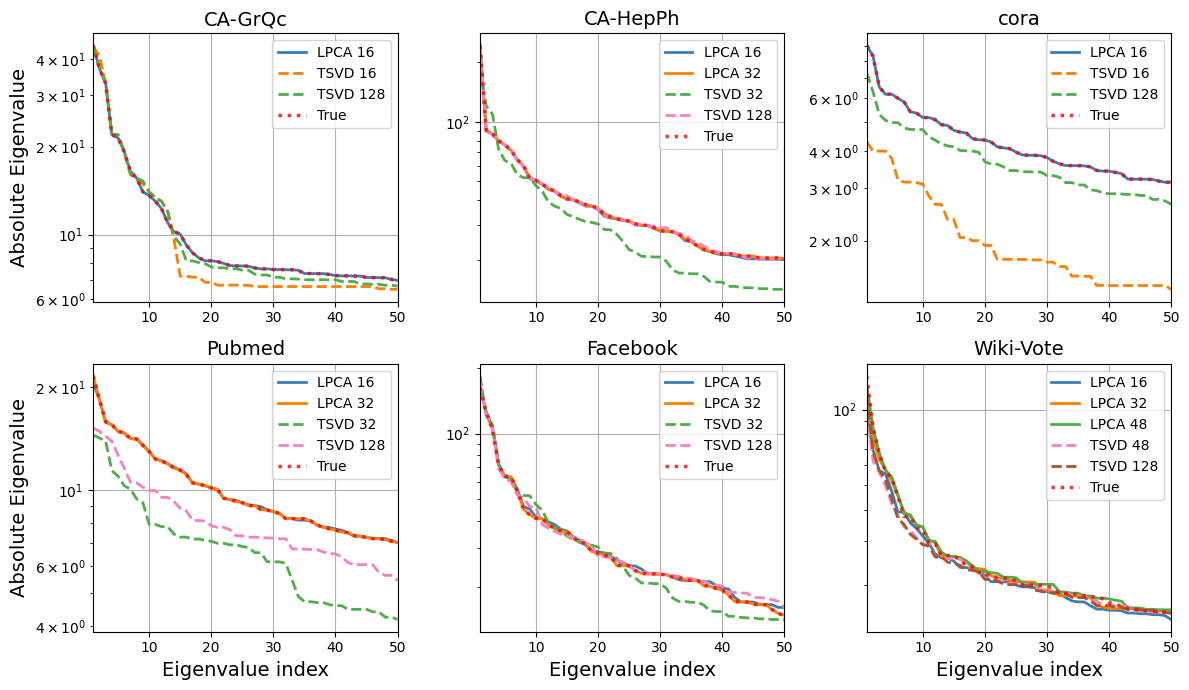

In [49]:
# fig = plot_eigenvalue_results(nbt_results, k=50)
# plt.savefig('./figs/ext-nbt.png', dpi=150, bbox_inches='tight')
# plt.show()

def plot_nbt_eigenvalue_results(results, dataset_order=None, k=50, figsize=(12, 7)):
    if dataset_order is None:
        dataset_order = list(results.keys())
    
    n_panels = min(len(dataset_order), 6)
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.flat
    
    for idx in range(n_panels):
        ax = axes[idx]
        dataset = dataset_order[idx]
        
        if dataset not in results or 'error' in results[dataset]:
            ax.set_title(f'{dataset}')
            continue
        
        data = results[dataset]
        eig_true = data['eig_true']
        x = np.arange(1, len(eig_true) + 1)
        
        for rank in sorted(data['lpca'].keys()):
            eig = data['lpca'][rank]['eig']
            err = data['lpca'][rank]['err']
            ax.semilogy(x[:len(eig)], eig, label=f'LPCA {rank}', linewidth=2)
        
        for rank in sorted(data['tsvd'].keys()):
            eig = data['tsvd'][rank]['eig']
            err = data['tsvd'][rank]['err']
            ax.semilogy(x[:len(eig)], eig, label=f'TSVD {rank}', linewidth=2, linestyle='--')
        
        ax.semilogy(x, eig_true, label='True', linewidth=2.5, linestyle=':', color='red', alpha=0.8)
        
        if idx in [3, 4, 5]:
            ax.set_xlabel('Eigenvalue index', fontsize=14)
        if idx in [0, 3]:
            ax.set_ylabel('Absolute Eigenvalue', fontsize=14)
        ax.set_title(f'{dataset}', fontsize=14)
        ax.grid()
        ax.legend(fontsize=10, loc='best')
        ax.set_xlim(1, k)
    
    for idx in range(n_panels, 6):
        axes[idx].axis('off')
    
    plt.tight_layout()
    return fig

fig = plot_nbt_eigenvalue_results(nbt_results, k=50)
plt.savefig('./figs/ext-nbt.png', dpi=150, bbox_inches='tight')
plt.show()